In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All libraries working. Day 1 complete.")

All libraries working. Day 1 complete.


In [29]:
# Horizontal charts are easier to read when words are long

plt.figure(figsize=(8, 6))
plt.barh(df_words["word"], df_words["count"], color="mediumseagreen")
plt.title("Top 10 Words — Horizontal")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()  # most frequent at top
plt.tight_layout()
plt.show()

NameError: name 'df_words' is not defined

<Figure size 800x600 with 0 Axes>

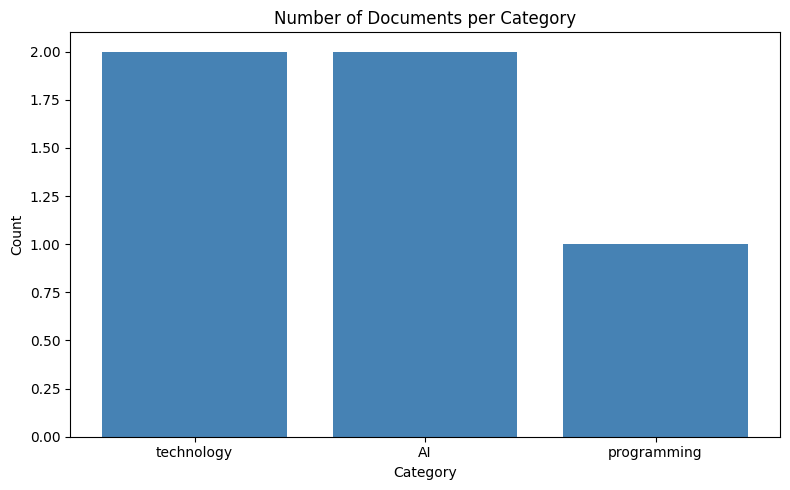

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Load your documents dataset
df = pd.read_csv("documents.csv")

# Count documents per category
category_counts = df["category"].value_counts()

# Plot it
plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values, color="steelblue")
plt.title("Number of Documents per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [17]:
# This is the most important block today
# You are now reading, cleaning and analyzing document data
# exactly like a real AI pipeline does

df = pd.read_csv("documents.csv")

# Clean the text — lowercase everything
df["clean_text"] = df["text"].str.lower()

# Remove punctuation
df["clean_text"] = df["clean_text"].str.replace("[^a-z\s]", "", regex=True)

# Count words in each document
df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))

# Find the document with most words
most_words = df.loc[df["word_count"].idxmax()]
print("Document with most words:")
print(most_words["text"])
print("Word count:", most_words["word_count"])

print("\nFull cleaned dataset:")
print(df[["document_id", "clean_text", "word_count", "category"]])

Document with most words:
Deep learning is a subset of machine learning
Word count: 8

Full cleaned dataset:
   document_id                                         clean_text  word_count  \
0            1          ai is transforming healthcare and finance           6   
1            2    python is the most popular programming language           7   
2            3     machine learning models require large datasets           6   
3            4      deep learning is a subset of machine learning           8   
4            5  australia is investing in artificial intelligence           6   

      category  
0   technology  
1  programming  
2           AI  
3           AI  
4   technology  


In [18]:
# GroupBy is extremely powerful
# It lets you summarize data by category
# You will use this constantly in data analysis

df = pd.read_csv("documents.csv")

# Average word count per category
grouped = df.groupby("category")["word_count"].mean()
print("Average word count per category:\n", grouped)

# Count how many documents per category
count_per_category = df.groupby("category")["document_id"].count()
print("\nDocuments per category:\n", count_per_category)

Average word count per category:
 category
AI             6.5
programming    7.0
technology     6.0
Name: word_count, dtype: float64

Documents per category:
 category
AI             2
programming    1
technology     2
Name: document_id, dtype: int64


In [19]:
df = pd.read_csv("documents.csv")

# Add a new column — length of each text
df["text_length"] = df["text"].apply(len)

# Add another column — whether text mentions AI
df["mentions_AI"] = df["text"].str.contains("AI|artificial intelligence", case=False)

print(df[["text", "text_length", "mentions_AI"]])

                                                text  text_length  mentions_AI
0          AI is transforming healthcare and finance           41         True
1    Python is the most popular programming language           47        False
2     Machine learning models require large datasets           46        False
3      Deep learning is a subset of machine learning           45        False
4  Australia is investing in artificial intelligence           49         True


In [20]:
# Real world data is always messy
# Missing values are one of the most common problems

# Create a messy dataset with missing values
messy_data = {
    "word": ["AI", "Python", None, "learning", "data", None],
    "count": [3, 2, 1, None, 4, 2],
    "category": ["tech", "programming", "tech", "AI", None, "AI"]
}

df_messy = pd.DataFrame(messy_data)
print("Before cleaning:\n", df_messy)
print("\nMissing values:\n", df_messy.isnull().sum())

# Drop rows with any missing values
df_clean = df_messy.dropna()
print("\nAfter dropping missing rows:\n", df_clean)

# OR fill missing values instead of dropping
df_filled = df_messy.fillna("unknown")
print("\nAfter filling missing values:\n", df_filled)

Before cleaning:
        word  count     category
0        AI    3.0         tech
1    Python    2.0  programming
2       NaN    1.0         tech
3  learning    NaN           AI
4      data    4.0          NaN
5       NaN    2.0           AI

Missing values:
 word        2
count       1
category    1
dtype: int64

After dropping missing rows:
      word  count     category
0      AI    3.0         tech
1  Python    2.0  programming

After filling missing values:
        word    count     category
0        AI      3.0         tech
1    Python      2.0  programming
2   unknown      1.0         tech
3  learning  unknown           AI
4      data      4.0      unknown
5   unknown      2.0           AI


In [21]:
# This is how you will read real documents in your project
df = pd.read_csv("documents.csv")

print("Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn info:")
print(df.info())

Shape: (5, 4)

First few rows:
   document_id                                               text  \
0            1          AI is transforming healthcare and finance   
1            2    Python is the most popular programming language   
2            3     Machine learning models require large datasets   
3            4      Deep learning is a subset of machine learning   
4            5  Australia is investing in artificial intelligence   

      category  word_count  
0   technology           6  
1  programming           7  
2           AI           6  
3           AI           7  
4   technology           6  

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   document_id  5 non-null      int64
 1   text         5 non-null      str  
 2   category     5 non-null      str  
 3   word_count   5 non-null      int64
dtypes: int64(2), str(2)
memory usage

In [22]:
import pandas as pd

# Create a fake dataset and save it as CSV
# This simulates what reading a real document dataset looks like

data = {
    "document_id": [1, 2, 3, 4, 5],
    "text": [
        "AI is transforming healthcare and finance",
        "Python is the most popular programming language",
        "Machine learning models require large datasets",
        "Deep learning is a subset of machine learning",
        "Australia is investing in artificial intelligence"
    ],
    "category": ["technology", "programming", "AI", "AI", "technology"],
    "word_count": [6, 7, 6, 7, 6]
}

df = pd.DataFrame(data)

# Save it as a CSV file
df.to_csv("documents.csv", index=False)
print("CSV file created successfully")
print(df)

CSV file created successfully
   document_id                                               text  \
0            1          AI is transforming healthcare and finance   
1            2    Python is the most popular programming language   
2            3     Machine learning models require large datasets   
3            4      Deep learning is a subset of machine learning   
4            5  Australia is investing in artificial intelligence   

      category  word_count  
0   technology           6  
1  programming           7  
2           AI           6  
3           AI           7  
4   technology           6  


In [23]:
# These are the commands you will use every single day
# Always run these first when you get any new data

print("Shape:", df.shape)           # rows and columns
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nBasic stats:\n", df.describe())
print("\nFirst 3 rows:\n", df.head(3))

Shape: (5, 4)

Column names: ['document_id', 'text', 'category', 'word_count']

Data types:
 document_id    int64
text             str
category         str
word_count     int64
dtype: object

Basic stats:
        document_id  word_count
count     5.000000    5.000000
mean      3.000000    6.400000
std       1.581139    0.547723
min       1.000000    6.000000
25%       2.000000    6.000000
50%       3.000000    6.000000
75%       4.000000    7.000000
max       5.000000    7.000000

First 3 rows:
    document_id                                             text     category  \
0            1        AI is transforming healthcare and finance   technology   
1            2  Python is the most popular programming language  programming   
2            3   Machine learning models require large datasets           AI   

   word_count  
0           6  
1           7  
2           6  


In [24]:
# Filtering means finding only the rows you care about
# Like searching for specific words in a document

# Show only words that appear more than once
frequent_words = df[df["count"] > 1]
print("Words appearing more than once:\n", frequent_words)

# Sort by count — highest first
sorted_df = df.sort_values("count", ascending=False)
print("\nSorted by frequency:\n", sorted_df)

KeyError: 'count'

In [ ]:
# Now combine everything — NumPy + Pandas together
# This is exactly how your Document Assistant will process text

document_text = """
AI is transforming the world. Python is the language of AI.
Machine learning is a subset of AI. Deep learning is powerful.
Australia needs more AI engineers. Python developers are in demand.
"""

# Step 1 - split into words and clean
words = document_text.lower().replace(".", "").replace(",", "").split()

# Step 2 - count frequencies
word_count = {}
for word in words:
    word_count[word] = word_count.get(word, 0) + 1

# Step 3 - put into a DataFrame
df_doc = pd.DataFrame(list(word_count.items()), columns=["word", "count"])

# Step 4 - sort by most frequent
df_doc = df_doc.sort_values("count", ascending=False)

print("Top 10 most frequent words:\n")
print(df_doc.head(10))

Top 10 most frequent words:

           word  count
0            ai      4
1            is      4
3           the      2
5        python      2
9      learning      2
7            of      2
4         world      1
2  transforming      1
6      language      1
8       machine      1


In [ ]:
import pandas as pd

# A DataFrame is like an Excel table in Python
# This is how we will store and analyze document data

data = {
    "word": ["AI", "Python", "future", "language", "learning"],
    "count": [3, 2, 1, 1, 2],
    "length": [2, 6, 6, 8, 8]
}

df = pd.DataFrame(data)
print(df)

       word  count  length
0        AI      3       2
1    Python      2       6
2    future      1       6
3  language      1       8
4  learning      2       8


In [ ]:
import numpy as np

# Slicing means grabbing specific parts of an array
# Just like grabbing specific words from a document

arr = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

print("Full array:", arr)
print("First 3 elements:", arr[:3])
print("Last 3 elements:", arr[-3:])
print("Middle elements:", arr[2:6])
print("Every 2nd element:", arr[::2])

Full array: [ 10  20  30  40  50  60  70  80  90 100]
First 3 elements: [10 20 30]
Last 3 elements: [ 80  90 100]
Middle elements: [30 40 50 60]
Every 2nd element: [10 30 50 70 90]


In [ ]:
# 2D arrays are like tables — rows and columns
# AI models store data exactly like this internally

matrix = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print("Full matrix:\n", matrix)
print("Shape:", matrix.shape)        # how many rows and columns
print("First row:", matrix[0])
print("Second column:", matrix[:, 1])
print("Single element row 1 col 2:", matrix[0][1])

Full matrix:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3)
First row: [1 2 3]
Second column: [2 5 8]
Single element row 1 col 2: 2


In [ ]:
# These operations are what AI uses to process data
# When AI reads your document, it does math like this on millions of numbers

a = np.array([1, 2, 3, 4, 5])
b = np.array([10, 20, 30, 40, 50])

print("Add:", a + b)
print("Multiply:", a * b)
print("Square root:", np.sqrt(b))
print("Sum of all:", np.sum(b))
print("Mean:", np.mean(b))
print("Standard deviation:", np.std(b))

Add: [11 22 33 44 55]
Multiply: [ 10  40  90 160 250]
Square root: [3.16227766 4.47213595 5.47722558 6.32455532 7.07106781]
Sum of all: 150
Mean: 30.0
Standard deviation: 14.142135623730951


In [ ]:
# A document is just a collection of words
# Lists and dictionaries are how we store and count them

sentence = "AI is the future and Python is the language of AI"

# Convert sentence into a list of words
words = sentence.split()
print("All words:", words)
print("Total words:", len(words))
print("Unique words:", len(set(words)))

All words: ['AI', 'is', 'the', 'future', 'and', 'Python', 'is', 'the', 'language', 'of', 'AI']
Total words: 11
Unique words: 8


In [ ]:
# Count how many times each word appears
word_count = {}

for word in words:
    if word in word_count:
        word_count[word] += 1
    else:
        word_count[word] = 1

print(word_count)

{'AI': 2, 'is': 2, 'the': 2, 'future': 1, 'and': 1, 'Python': 1, 'language': 1, 'of': 1}


In [ ]:
import numpy as np

# Convert counts into a NumPy array
counts = np.array(list(word_count.values()))
labels = np.array(list(word_count.keys()))

print("Words:", labels)
print("Counts:", counts)
print("Most repeated word appears:", np.max(counts), "times")
print("Average frequency:", np.mean(counts))

Words: ['AI' 'is' 'the' 'future' 'and' 'Python' 'language' 'of']
Counts: [2 2 2 1 1 1 1 1]
Most repeated word appears: 2 times
Average frequency: 1.375


In [ ]:
# NumPy makes math on arrays super fast
numbers = np.array([10, 20, 30, 40, 50])

print("Sum:", np.sum(numbers))
print("Mean:", np.mean(numbers))
print("Max:", np.max(numbers))
print("Min:", np.min(numbers))

# Multiply every number by 2 in one line — no loop needed
print("Doubled:", numbers * 2)

Sum: 150
Mean: 30.0
Max: 50
Min: 10
Doubled: [ 20  40  60  80 100]


In [ ]:
# This is the foundation of your AI Document Assistant
# Right now we are manually typing the text
# In Week 3 this will read a real PDF file automatically

document_text = """
Artificial intelligence is transforming the world. 
Python is the most popular language for AI development.
Machine learning and deep learning are subsets of AI.
Australia is investing heavily in AI and technology.
"""

words = document_text.lower().split()
print("Document has", len(words), "words")
print("Unique words:", len(set(words)))

Document has 32 words
Unique words: 26


In [30]:
import re
import pandas as pd

# re is Python's built-in library for text pattern matching

raw_text = """
Hello! This is a Sample Document. It contains: numbers 123, 
punctuation!!!, UPPERCASE letters, and    extra   spaces.
Visit https://www.google.com for more info.
"""

# Step 1 - lowercase
text = raw_text.lower()
print("After lowercase:\n", text)

# Step 2 - remove URLs
text = re.sub(r'http\S+', '', text)
print("\nAfter removing URLs:\n", text)

# Step 3 - remove punctuation and numbers
text = re.sub(r'[^a-z\s]', '', text)
print("\nAfter removing punctuation:\n", text)

# Step 4 - remove extra spaces
text = re.sub(r'\s+', ' ', text).strip()
print("\nFinal cleaned text:\n", text)

After lowercase:
 
hello! this is a sample document. it contains: numbers 123, 
punctuation!!!, uppercase letters, and    extra   spaces.
visit https://www.google.com for more info.


After removing URLs:
 
hello! this is a sample document. it contains: numbers 123, 
punctuation!!!, uppercase letters, and    extra   spaces.
visit  for more info.


After removing punctuation:
 
hello this is a sample document it contains numbers  
punctuation uppercase letters and    extra   spaces
visit  for more info


Final cleaned text:
 hello this is a sample document it contains numbers punctuation uppercase letters and extra spaces visit for more info


In [31]:
# Tokenization means splitting text into individual units
# Every AI model starts with tokenization

sentence = "Machine learning is transforming the technology industry"

# Word tokenization — split into words
words = sentence.split()
print("Word tokens:", words)
print("Total tokens:", len(words))

# Character tokenization — split into characters
chars = list(sentence)
print("\nFirst 10 character tokens:", chars[:10])

# Sentence tokenization — split paragraph into sentences
paragraph = "AI is powerful. Python is popular. Australia needs engineers."
sentences = paragraph.split(".")
sentences = [s.strip() for s in sentences if s.strip()]
print("\nSentence tokens:", sentences)

Word tokens: ['Machine', 'learning', 'is', 'transforming', 'the', 'technology', 'industry']
Total tokens: 7

First 10 character tokens: ['M', 'a', 'c', 'h', 'i', 'n', 'e', ' ', 'l', 'e']

Sentence tokens: ['AI is powerful', 'Python is popular', 'Australia needs engineers']


In [32]:
# Stopwords are common words that carry no meaning
# Words like "the", "is", "and", "a" tell us nothing about a document
# Removing them helps AI focus on meaningful words

stopwords = set([
    "is", "the", "a", "an", "and", "or", "but", "in", 
    "on", "at", "to", "for", "of", "with", "it", "this",
    "that", "are", "was", "be", "has", "have", "will"
])

text = "machine learning is the most powerful tool in the field of artificial intelligence"
words = text.split()

# Remove stopwords
filtered_words = [word for word in words if word not in stopwords]

print("Original:", words)
print("\nAfter stopword removal:", filtered_words)
print("\nRemoved", len(words) - len(filtered_words), "stopwords")

Original: ['machine', 'learning', 'is', 'the', 'most', 'powerful', 'tool', 'in', 'the', 'field', 'of', 'artificial', 'intelligence']

After stopword removal: ['machine', 'learning', 'most', 'powerful', 'tool', 'field', 'artificial', 'intelligence']

Removed 5 stopwords


In [33]:
# Stemming cuts words down to their root form
# "running", "runs", "runner" all become "run"
# This helps AI treat these as the same word

# Simple manual stemmer to understand the concept
def simple_stem(word):
    suffixes = ["ing", "ed", "er", "ly", "tion", "ness"]
    for suffix in suffixes:
        if word.endswith(suffix) and len(word) > len(suffix) + 2:
            return word[:-len(suffix)]
    return word

test_words = ["running", "jumped", "quickly", "learning", 
              "processed", "transformation", "darkness"]

for word in test_words:
    print(f"{word} → {simple_stem(word)}")

running → runn
jumped → jump
quickly → quick
learning → learn
processed → process
transformation → transforma
darkness → dark


In [34]:
# Bag of Words converts text into numbers
# This is how machines read text — as numbers, not words
# Every unique word becomes a column, every document becomes a row

documents = [
    "AI is transforming healthcare",
    "Python is used for AI development", 
    "Machine learning needs data",
    "AI and machine learning are related"
]

# Step 1 - build vocabulary of all unique words
all_words = set()
for doc in documents:
    for word in doc.lower().split():
        all_words.add(word)

vocabulary = sorted(list(all_words))
print("Vocabulary:", vocabulary)
print("Vocabulary size:", len(vocabulary))

# Step 2 - represent each document as a vector of word counts
import numpy as np

def text_to_vector(text, vocab):
    words = text.lower().split()
    vector = np.zeros(len(vocab))
    for word in words:
        if word in vocab:
            vector[vocab.index(word)] += 1
    return vector

# Convert all documents
vectors = np.array([text_to_vector(doc, vocabulary) for doc in documents])

df_bow = pd.DataFrame(vectors, columns=vocabulary)
df_bow.index = ["Doc1", "Doc2", "Doc3", "Doc4"]
print("\nBag of Words matrix:")
print(df_bow)

Vocabulary: ['ai', 'and', 'are', 'data', 'development', 'for', 'healthcare', 'is', 'learning', 'machine', 'needs', 'python', 'related', 'transforming', 'used']
Vocabulary size: 15

Bag of Words matrix:
       ai  and  are  data  development  for  healthcare   is  learning  \
Doc1  1.0  0.0  0.0   0.0          0.0  0.0         1.0  1.0       0.0   
Doc2  1.0  0.0  0.0   0.0          1.0  1.0         0.0  1.0       0.0   
Doc3  0.0  0.0  0.0   1.0          0.0  0.0         0.0  0.0       1.0   
Doc4  1.0  1.0  1.0   0.0          0.0  0.0         0.0  0.0       1.0   

      machine  needs  python  related  transforming  used  
Doc1      0.0    0.0     0.0      0.0           1.0   0.0  
Doc2      0.0    0.0     1.0      0.0           0.0   1.0  
Doc3      1.0    1.0     0.0      0.0           0.0   0.0  
Doc4      1.0    0.0     0.0      1.0           0.0   0.0  


In [35]:
# Full text preprocessing pipeline for your AI Document Assistant
# This is exactly what will run when a user uploads a document

def preprocess_document(text):
    # Step 1 - lowercase
    text = text.lower()
    
    # Step 2 - remove URLs
    text = re.sub(r'http\S+', '', text)
    
    # Step 3 - remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Step 4 - remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Step 5 - tokenize
    words = text.split()
    
    # Step 6 - remove stopwords
    stopwords = set(["is", "the", "a", "an", "and", "or", 
                     "but", "in", "on", "at", "to", "for", 
                     "of", "with", "it", "this", "that", "are"])
    
    words = [word for word in words if word not in stopwords]
    
    return words

# Test it on a real document
sample_document = """
Artificial intelligence is transforming the way we work and live.
Python is the most popular language for AI development in 2026.
Australia is investing heavily in technology and AI infrastructure.
"""

processed = preprocess_document(sample_document)
print("Processed words:", processed)
print("\nTotal meaningful words:", len(processed))
print("\nTop unique words:", sorted(set(processed)))

Processed words: ['artificial', 'intelligence', 'transforming', 'way', 'we', 'work', 'live', 'python', 'most', 'popular', 'language', 'ai', 'development', 'australia', 'investing', 'heavily', 'technology', 'ai', 'infrastructure']

Total meaningful words: 19

Top unique words: ['ai', 'artificial', 'australia', 'development', 'heavily', 'infrastructure', 'intelligence', 'investing', 'language', 'live', 'most', 'popular', 'python', 'technology', 'transforming', 'way', 'we', 'work']


In [37]:
import re

# Regex = Regular Expressions
# A powerful way to find and extract patterns in text
# Used in every text processing pipeline in the world

text = """
Contact us at support@company.com or sales@business.org
Call us at +91-9876543210 or +1-555-123-4567
Visit https://www.example.com or http://test.org
Order ID: ORD-12345, Invoice: INV-67890
"""

# Extract all email addresses
emails = re.findall(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', text)
print("Emails found:", emails)

# Extract all phone numbers
phones = re.findall(r'\+\d{1,3}-\d{10}|\+\d{1,3}-\d{3}-\d{3}-\d{4}', text)
print("Phones found:", phones)

# Extract all URLs
urls = re.findall(r'https?://\S+', text)
print("URLs found:", urls)

# Extract all IDs
ids = re.findall(r'[A-Z]+-\d+', text)
print("IDs found:", ids)

Emails found: ['support@company.com', 'sales@business.org']
Phones found: ['+91-9876543210', '+1-555-123-4567']
URLs found: ['https://www.example.com', 'http://test.org']
IDs found: ['ORD-12345', 'INV-67890']


In [38]:
# These are the regex patterns you will use most in your project

sample = "Hello!!! This is    a TEST document... with NUMBERS 12345 and symbols @#$%"

# Remove special characters but keep spaces
clean1 = re.sub(r'[^a-zA-Z\s]', '', sample)
print("Remove special chars:", clean1)

# Remove extra whitespace
clean2 = re.sub(r'\s+', ' ', clean1).strip()
print("Remove extra spaces:", clean2)

# Replace multiple punctuation
clean3 = re.sub(r'[!?.]+', '.', sample)
print("Clean punctuation:", clean3)

# Extract only words (no numbers, no symbols)
words_only = re.findall(r'\b[a-zA-Z]+\b', sample)
print("Words only:", words_only)

Remove special chars: Hello This is    a TEST document with NUMBERS  and symbols 
Remove extra spaces: Hello This is a TEST document with NUMBERS and symbols
Clean punctuation: Hello. This is    a TEST document. with NUMBERS 12345 and symbols @#$%
Words only: ['Hello', 'This', 'is', 'a', 'TEST', 'document', 'with', 'NUMBERS', 'and', 'symbols']


In [39]:
import numpy as np
import pandas as pd

# TF-IDF = Term Frequency - Inverse Document Frequency
# It answers one question:
# "How important is this word to THIS document compared to ALL documents?"

# TERM FREQUENCY (TF)
# How often a word appears in ONE document
# TF = word count in document / total words in document

def calculate_tf(document):
    words = document.lower().split()
    total_words = len(words)
    tf = {}
    for word in words:
        tf[word] = tf.get(word, 0) + 1
    # Divide by total words to normalize
    for word in tf:
        tf[word] = tf[word] / total_words
    return tf

doc1 = "AI is transforming healthcare and finance"
tf_doc1 = calculate_tf(doc1)
print("TF for doc1:")
for word, score in sorted(tf_doc1.items(), key=lambda x: x[1], reverse=True):
    print(f"  {word}: {score:.3f}")

TF for doc1:
  ai: 0.167
  is: 0.167
  transforming: 0.167
  healthcare: 0.167
  and: 0.167
  finance: 0.167


In [40]:
import numpy as np
import pandas as pd

# TF-IDF = Term Frequency - Inverse Document Frequency
# It answers one question:
# "How important is this word to THIS document compared to ALL documents?"

# TERM FREQUENCY (TF)
# How often a word appears in ONE document
# TF = word count in document / total words in document

def calculate_tf(document):
    words = document.lower().split()
    total_words = len(words)
    tf = {}
    for word in words:
        tf[word] = tf.get(word, 0) + 1
    # Divide by total words to normalize
    for word in tf:
        tf[word] = tf[word] / total_words
    return tf

doc1 = "AI is transforming healthcare and finance"
tf_doc1 = calculate_tf(doc1)
print("TF for doc1:")
for word, score in sorted(tf_doc1.items(), key=lambda x: x[1], reverse=True):
    print(f"  {word}: {score:.3f}")

TF for doc1:
  ai: 0.167
  is: 0.167
  transforming: 0.167
  healthcare: 0.167
  and: 0.167
  finance: 0.167


In [41]:
import math

# INVERSE DOCUMENT FREQUENCY (IDF)
# Measures how RARE a word is across ALL documents
# Common words like "is", "the" appear everywhere → low IDF
# Rare important words like "healthcare" appear rarely → high IDF
# IDF = log(total documents / documents containing the word)

documents = [
    "AI is transforming healthcare and finance",
    "Python is the language of AI development",
    "Machine learning needs large datasets and data",
    "Healthcare AI is improving patient outcomes",
    "Finance and banking are using AI solutions"
]

def calculate_idf(documents):
    total_docs = len(documents)
    idf = {}
    
    # Find all unique words
    all_words = set()
    for doc in documents:
        for word in doc.lower().split():
            all_words.add(word)
    
    # Count in how many documents each word appears
    for word in all_words:
        doc_count = sum(1 for doc in documents if word in doc.lower().split())
        idf[word] = math.log(total_docs / doc_count)
    
    return idf

idf_scores = calculate_idf(documents)

# Show highest IDF words — these are the most unique/important words
sorted_idf = sorted(idf_scores.items(), key=lambda x: x[1], reverse=True)
print("Words with highest IDF (most unique):")
for word, score in sorted_idf[:10]:
    print(f"  {word}: {score:.3f}")

print("\nWords with lowest IDF (most common):")
for word, score in sorted_idf[-5:]:
    print(f"  {word}: {score:.3f}")

Words with highest IDF (most unique):
  data: 1.609
  language: 1.609
  of: 1.609
  python: 1.609
  using: 1.609
  solutions: 1.609
  needs: 1.609
  development: 1.609
  patient: 1.609
  learning: 1.609

Words with lowest IDF (most common):
  healthcare: 0.916
  finance: 0.916
  and: 0.511
  is: 0.511
  ai: 0.223


In [42]:
# TF-IDF = TF × IDF
# High TF-IDF means the word is frequent in THIS document
# but rare across ALL documents → truly important word

def calculate_tfidf(document, all_documents):
    tf = calculate_tf(document)
    idf = calculate_idf(all_documents)
    
    tfidf = {}
    for word in tf:
        tfidf[word] = tf[word] * idf.get(word, 0)
    
    return tfidf

# Calculate TF-IDF for first document
tfidf_doc1 = calculate_tfidf(documents[0], documents)

print("TF-IDF scores for:", documents[0])
print()
sorted_tfidf = sorted(tfidf_doc1.items(), key=lambda x: x[1], reverse=True)
for word, score in sorted_tfidf:
    print(f"  {word}: {score:.4f}")

print("\nMost important word in this document:", sorted_tfidf[0][0])

TF-IDF scores for: AI is transforming healthcare and finance

  transforming: 0.2682
  healthcare: 0.1527
  finance: 0.1527
  is: 0.0851
  and: 0.0851
  ai: 0.0372

Most important word in this document: transforming


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Scikit-learn does all the TF-IDF math automatically
# You built it manually above to understand it
# Now use the library version — this is what you'll use in real projects

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(documents)

# Convert to DataFrame to see it clearly
feature_names = vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=[f"Doc{i+1}" for i in range(len(documents))]
)

print("TF-IDF Matrix:")
print(df_tfidf.round(3))
print("\nShape:", df_tfidf.shape)

TF-IDF Matrix:
         ai    and   are  banking   data  datasets  development  finance  \
Doc1  0.300  0.357  0.00     0.00  0.000     0.000        0.000    0.430   
Doc2  0.235  0.000  0.00     0.00  0.000     0.000        0.416    0.000   
Doc3  0.000  0.264  0.00     0.00  0.394     0.394        0.000    0.000   
Doc4  0.268  0.000  0.00     0.00  0.000     0.000        0.000    0.000   
Doc5  0.242  0.288  0.43     0.43  0.000     0.000        0.000    0.347   

      healthcare  improving  ...  machine  needs     of  outcomes  patient  \
Doc1       0.430      0.000  ...    0.000  0.000  0.000     0.000    0.000   
Doc2       0.000      0.000  ...    0.000  0.000  0.416     0.000    0.000   
Doc3       0.000      0.000  ...    0.394  0.394  0.000     0.000    0.000   
Doc4       0.384      0.476  ...    0.000  0.000  0.000     0.476    0.476   
Doc5       0.000      0.000  ...    0.000  0.000  0.000     0.000    0.000   

      python  solutions    the  transforming  using  
Doc1 

In [45]:
# Finding the most important words in your document using TF-IDF
# This is exactly what your AI Document Assistant will use
# to understand what a document is about

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Simulate a user uploading a document
user_document = """
Artificial intelligence is revolutionizing the healthcare industry.
Machine learning models can predict diseases before symptoms appear.
Deep learning algorithms analyze medical images with high accuracy.
AI powered diagnostic tools are helping doctors make better decisions.
Python is the primary language used to build these healthcare AI systems.
Australia is investing in AI healthcare solutions for rural communities.
"""

# Split into sentences — each sentence is treated as a mini document
sentences = [s.strip() for s in user_document.split(".") if s.strip()]

# Apply TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(sentences)

# Find most important words overall
feature_names = vectorizer.get_feature_names_out()
scores = tfidf_matrix.sum(axis=0).A1
word_scores = pd.DataFrame({
    "word": feature_names,
    "importance": scores
}).sort_values("importance", ascending=False)

print("Top 10 most important words in your document:")
print(word_scores.head(10).to_string(index=False))
print("\nThis is what your AI uses to understand your document.")

Top 10 most important words in your document:
           word  importance
     healthcare    0.873175
             ai    0.783813
       learning    0.613496
       industry    0.472493
   intelligence    0.472493
     artificial    0.472493
revolutionizing    0.472493
      solutions    0.409664
          rural    0.409664
      investing    0.409664

This is what your AI uses to understand your document.
